<a href="https://colab.research.google.com/github/kurowskitomek/AircraftAccidents/blob/main/AircraftAccidents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("saurograndi/airplane-crashes-since-1908")

100%|██████████| 564k/564k [00:00<00:00, 696kB/s]

Extracting files...


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

Wczytanie danych

In [7]:
import os
df = pd.read_csv(os.path.join(path, 'Airplane_Crashes_and_Fatalities_Since_1908.csv'))
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


Podstawowe informacje

In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          5268 non-null   datetime64[ns]
 1   Time          3049 non-null   object        
 2   Location      5248 non-null   object        
 3   Operator      5250 non-null   object        
 4   Flight #      1069 non-null   object        
 5   Route         3561 non-null   object        
 6   Type          5241 non-null   object        
 7   Registration  4933 non-null   object        
 8   cn/In         4040 non-null   object        
 9   Aboard        5246 non-null   float64       
 10  Fatalities    5256 non-null   float64       
 11  Ground        5246 non-null   float64       
 12  Summary       4878 non-null   object        
 13  Year          5268 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(1), object(9)
memory usage: 555.7+ KB


,Date,Aboard,Fatalities,Ground,Year
count,5268,5246.000000,5256.000000,5246.000000,5268.000000
mean,1971-10-23 15:50:42.369020480,27.554518,20.068303,1.608845,1971.300304
min,1908-09-17 00:00:00,0.000000,0.000000,0.000000,1908.000000
25%,1954-04-11 18:00:00,5.000000,3.000000,0.000000,1954.000000
50%,1973-03-04 00:00:00,13.000000,9.000000,0.000000,1973.000000
75%,1990-06-26 18:00:00,30.000000,23.000000,0.000000,1990.000000
max,2009-06-08 00:00:00,644.000000,583.000000,2750.000000,2009.000000
std,NaN,43.076711,33.199952,53.987827,22.387541


Braki danych

In [10]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


Czyszczenie

In [11]:
df = df.drop_duplicates()

df["Aboard"] = pd.to_numeric(df["Aboard"], errors="coerce")
df["Fatalities"] = pd.to_numeric(df["Fatalities"], errors="coerce")
df["Ground"] = pd.to_numeric(df["Ground"], errors="coerce")

#Tworzenie nowych zmiennych

FatalityRate

In [12]:
df["FatalityRate"] = (
    df["Fatalities"] /
    df["Aboard"]
) * 100

Rok

In [13]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

Dekada

In [14]:
df["Decade"] = (df["Year"] // 10) * 10

OperatorType

In [16]:
df["OperatorType"] = np.where(
    df["Operator"].str.contains(
        "air force|army|military|navy",
        case=False,
        na=False
    ),
    "Military",
    "Civil"
)

#Hipoteza H1
Zmienna zależna:


*   FatalityRate

Predyktory:


*   Aboard
*   AC Type
*   Ground


#Hipoteza H2
Zmienna zależna:


*   Fatalities

Predyktory:


*   Aboard
*   Ground
*   Year


#Hipoteza H3
Zmienna zależna:


*   OperatorType

Predyktory:


*   AC Type
*   Decade
*   FatalityRate

#Statystyki Opisowe

Funkcja generująca statystyki

In [17]:
def descriptive_stats(series):

    return pd.Series({
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0],
        "min": series.min(),
        "max": series.max(),
        "std": series.std(),
        "variance": series.var()
    })

Wszystkie zmienne ilościowe

In [18]:
quantitative = [
    "Aboard",
    "Fatalities",
    "Ground",
    "FatalityRate"
]

stats_table = pd.DataFrame()

for col in quantitative:
    stats_table[col] = descriptive_stats(df[col])

stats_table

,Aboard,Fatalities,Ground,FatalityRate
count,5246.000000,5256.000000,5246.000000,5244.000000
mean,27.554518,20.068303,1.608845,83.493160
median,13.000000,9.000000,0.000000,100.000000
mode,2.000000,2.000000,0.000000,100.000000
min,0.000000,0.000000,0.000000,0.000000
max,644.000000,583.000000,2750.000000,100.000000
std,43.076711,33.199952,53.987827,29.877115
variance,1855.603033,1102.236818,2914.685481,892.641978


Tabele liczności

In [19]:
df["OperatorType"].value_counts()

,count
OperatorType,
Civil,4477
Military,791


In [20]:
df["Decade"].value_counts()

,count
Decade,
1970,837
1990,775
1960,721
1980,717
1950,596
2000,583
1940,510
1930,323
1920,178


Tabela wielodzielcza

In [21]:
pd.crosstab(
    df["OperatorType"],
    df["Decade"]
)

Decade,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000
OperatorType,,,,,,,,,,,
Civil,0,8,172,318,370,502,596,740,597,670,504
Military,1,19,6,5,140,94,125,97,120,105,79


Histogramy

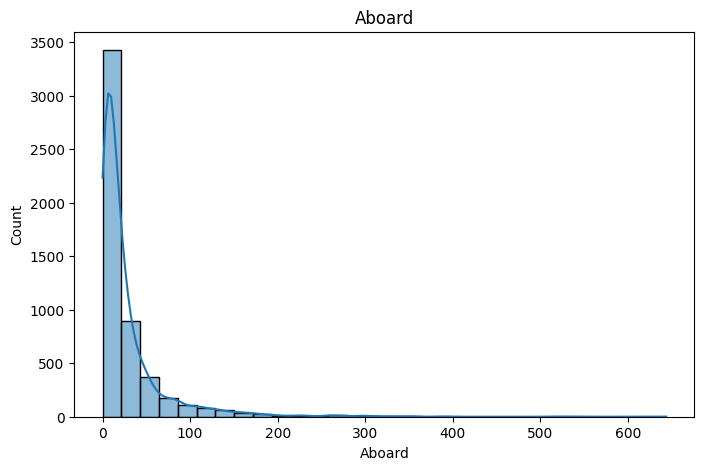

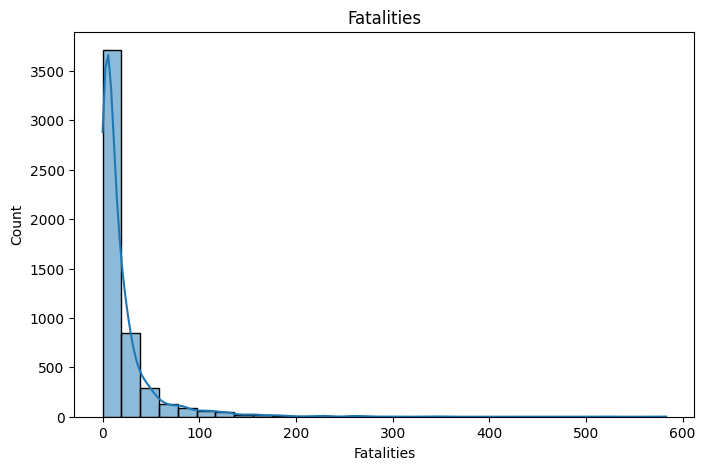

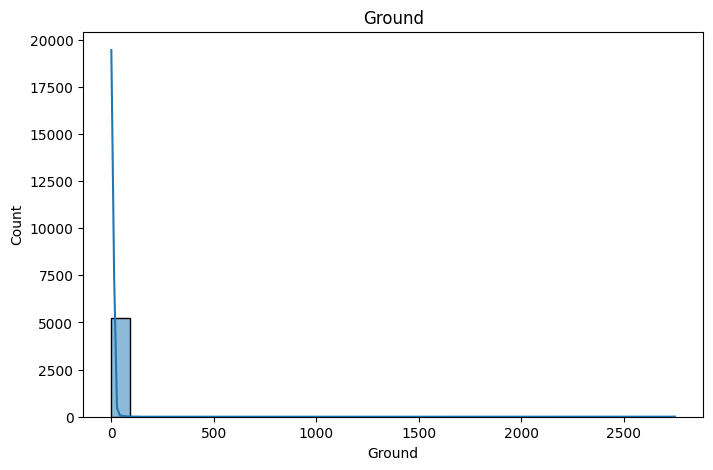

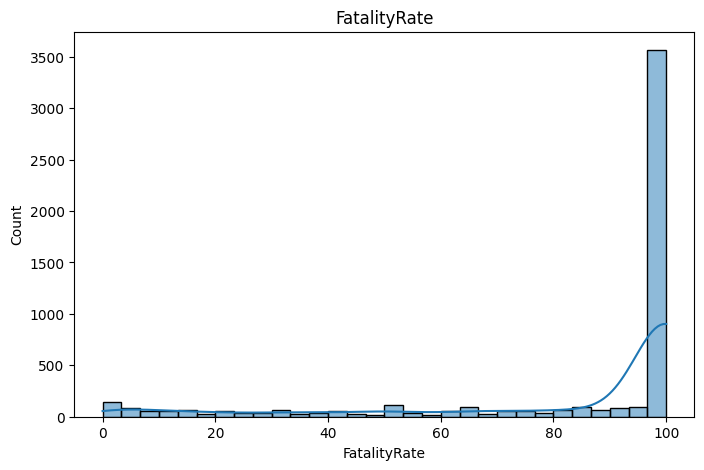

In [22]:
for col in quantitative:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )

    plt.title(col)
    plt.show()

Histogram skategoryzowany

<Axes: xlabel='FatalityRate', ylabel='Count'>

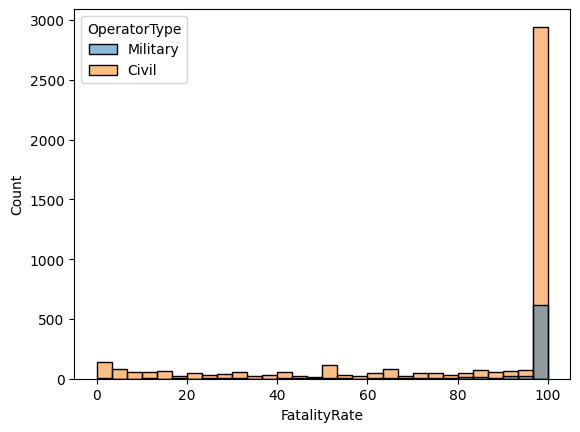

In [23]:
sns.histplot(
    data=df,
    x="FatalityRate",
    hue="OperatorType",
    bins=30
)

Wykres średnich w grupach

<Axes: xlabel='OperatorType'>

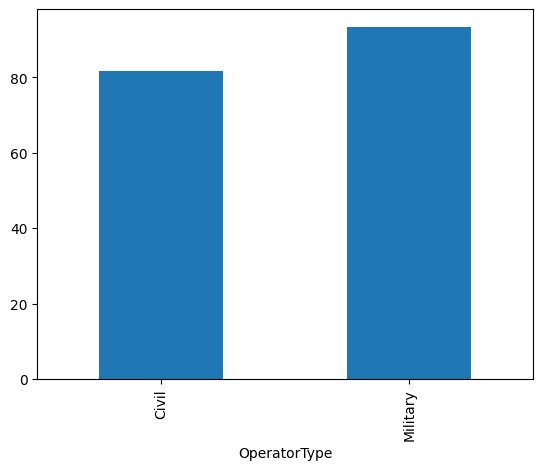

In [24]:
means = df.groupby(
    "OperatorType"
)["FatalityRate"].mean()

means.plot(
    kind="bar"
)

Macierz korelacji

In [25]:
corr = df[
    [
        "Aboard",
        "Fatalities",
        "Ground",
        "FatalityRate"
    ]
].corr()

corr

,Aboard,Fatalities,Ground,FatalityRate
Aboard,1.000000,0.757172,0.023241,-0.227193
Fatalities,0.757172,1.000000,0.035170,0.186248
Ground,0.023241,0.035170,1.000000,0.008693
FatalityRate,-0.227193,0.186248,0.008693,1.000000


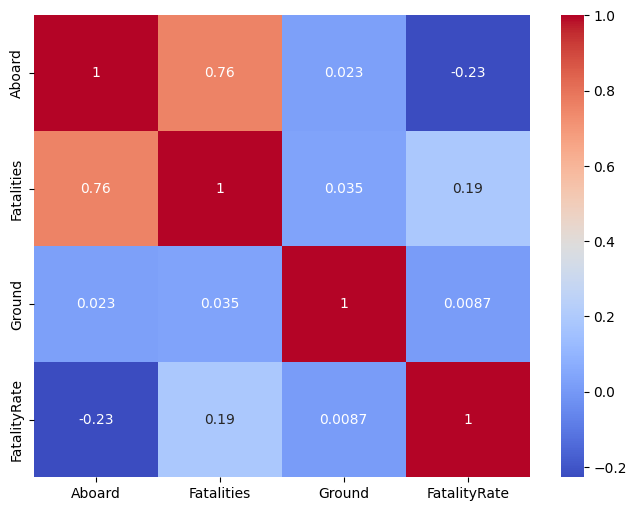

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Test Chi^2

In [27]:
table = pd.crosstab(
    df["OperatorType"],
    df["Decade"]
)

chi2, p, dof, exp = chi2_contingency(table)

print(chi2)
print(p)

212.0887957822937
4.82811829603735e-40


Ważność predyktorów (Chi^2)

<Axes: >

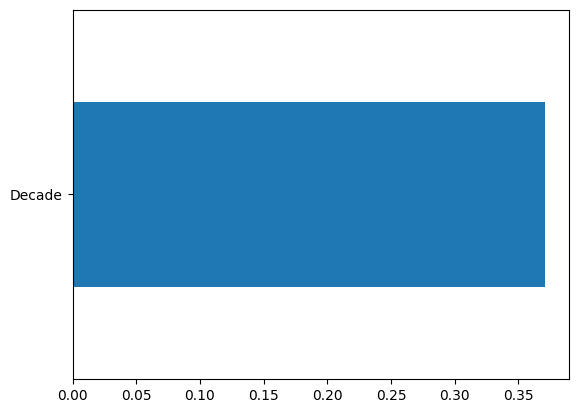

In [28]:
from sklearn.feature_selection import chi2

X = pd.get_dummies(
    df[["Decade"]],
    drop_first=True
)

y = LabelEncoder().fit_transform(
    df["OperatorType"]
)

chi_values, p = chi2(X, y)

importance = pd.Series(
    chi_values,
    index=X.columns
)

importance.sort_values().plot.barh()

Boxploty

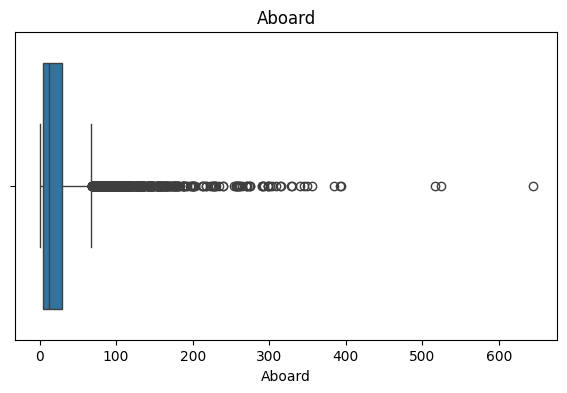

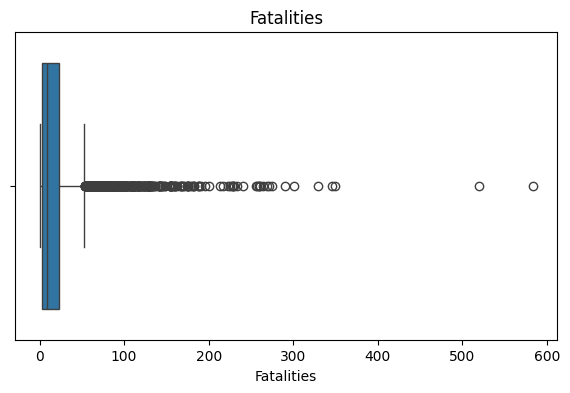

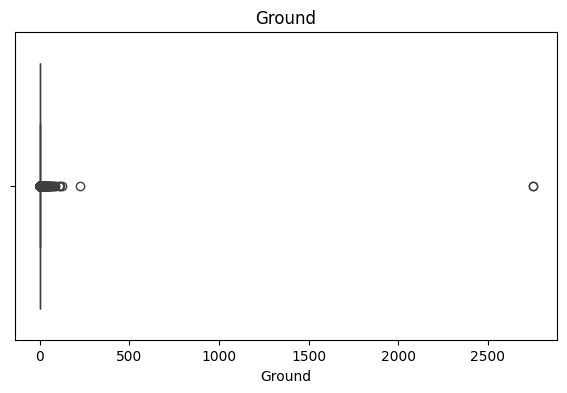

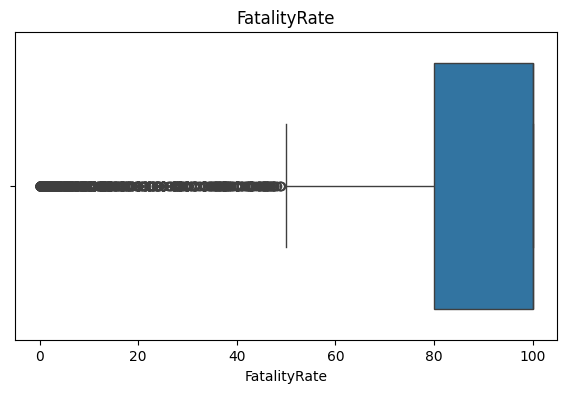

In [29]:
for col in quantitative:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

Boxplot skategoryzowany

<Axes: xlabel='OperatorType', ylabel='FatalityRate'>

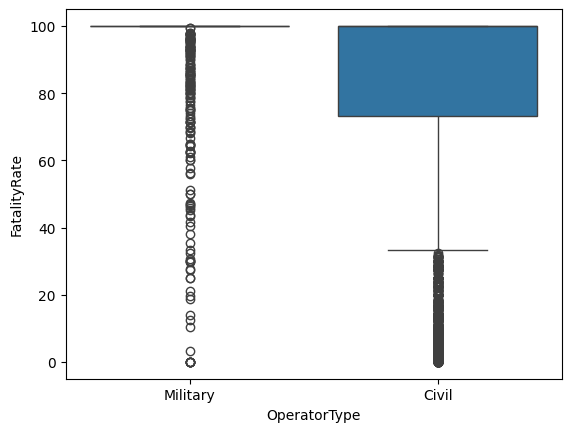

In [30]:
sns.boxplot(
    data=df,
    x="OperatorType",
    y="FatalityRate"
)

Test normalności

In [31]:
for col in quantitative:

    stat, p = stats.shapiro(
        df[col].dropna().sample(
            min(5000,
            len(df[col].dropna()))
        )
    )

    print(col, p)

Aboard 9.71104126232699e-77
Fatalities 6.108303702120229e-78
Ground 1.2979836128308075e-95
FatalityRate 7.368618084607863e-75


Odstające

In [39]:
non_nan_fatality_rate = df["FatalityRate"].dropna()
z_scores = stats.zscore(non_nan_fatality_rate)
abs_z_scores = np.abs(z_scores)

# Create a boolean series with the same index as the original DataFrame
outlier_mask = pd.Series(False, index=df.index)
outlier_mask[non_nan_fatality_rate.index] = abs_z_scores > 3

outliers = df[outlier_mask]

Scatterploty

<Axes: xlabel='Aboard', ylabel='Fatalities'>

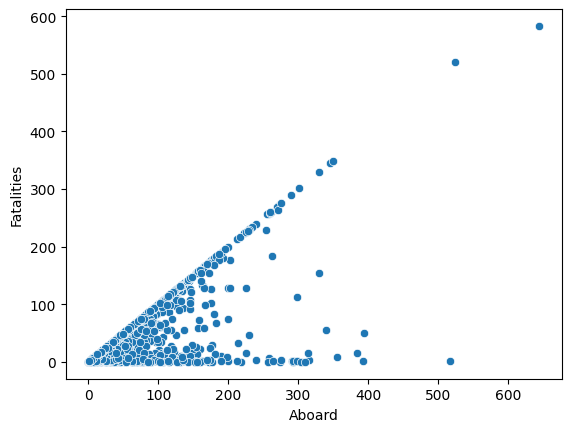

In [34]:
sns.scatterplot(
    data=df,
    x="Aboard",
    y="Fatalities"
)

<Axes: xlabel='Aboard', ylabel='Fatalities'>

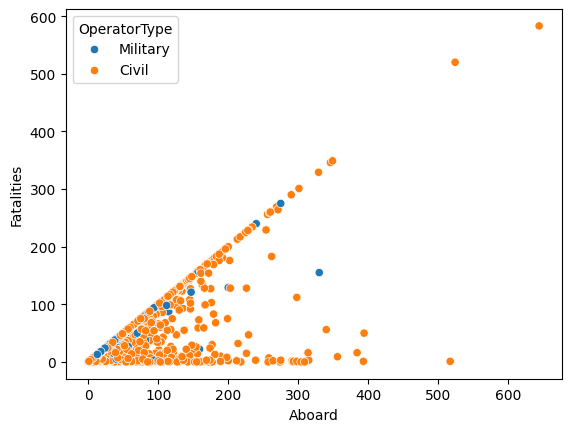

In [35]:
sns.scatterplot(
    data=df,
    x="Aboard",
    y="Fatalities",
    hue="OperatorType"
)

#Drzewa decyzyjne

Drzewo regresyjne

In [45]:
X_cols = ["Aboard", "Ground"]
y_col = "FatalityRate"

# Create a temporary DataFrame with both features and target
temp_df = df[X_cols + [y_col]].copy()

# Drop rows where any of these columns have NaN values
temp_df.dropna(inplace=True)

X = temp_df[X_cols]
y = temp_df[y_col]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [47]:
tree = DecisionTreeRegressor(
    max_depth=4
)

tree.fit(
    X_train,
    y_train
)

DecisionTreeRegressor(max_depth=4)

In [48]:
pred = tree.predict(X_test)

r2 = r2_score(
    y_test,
    pred
)

print(r2)

0.05071438057475497


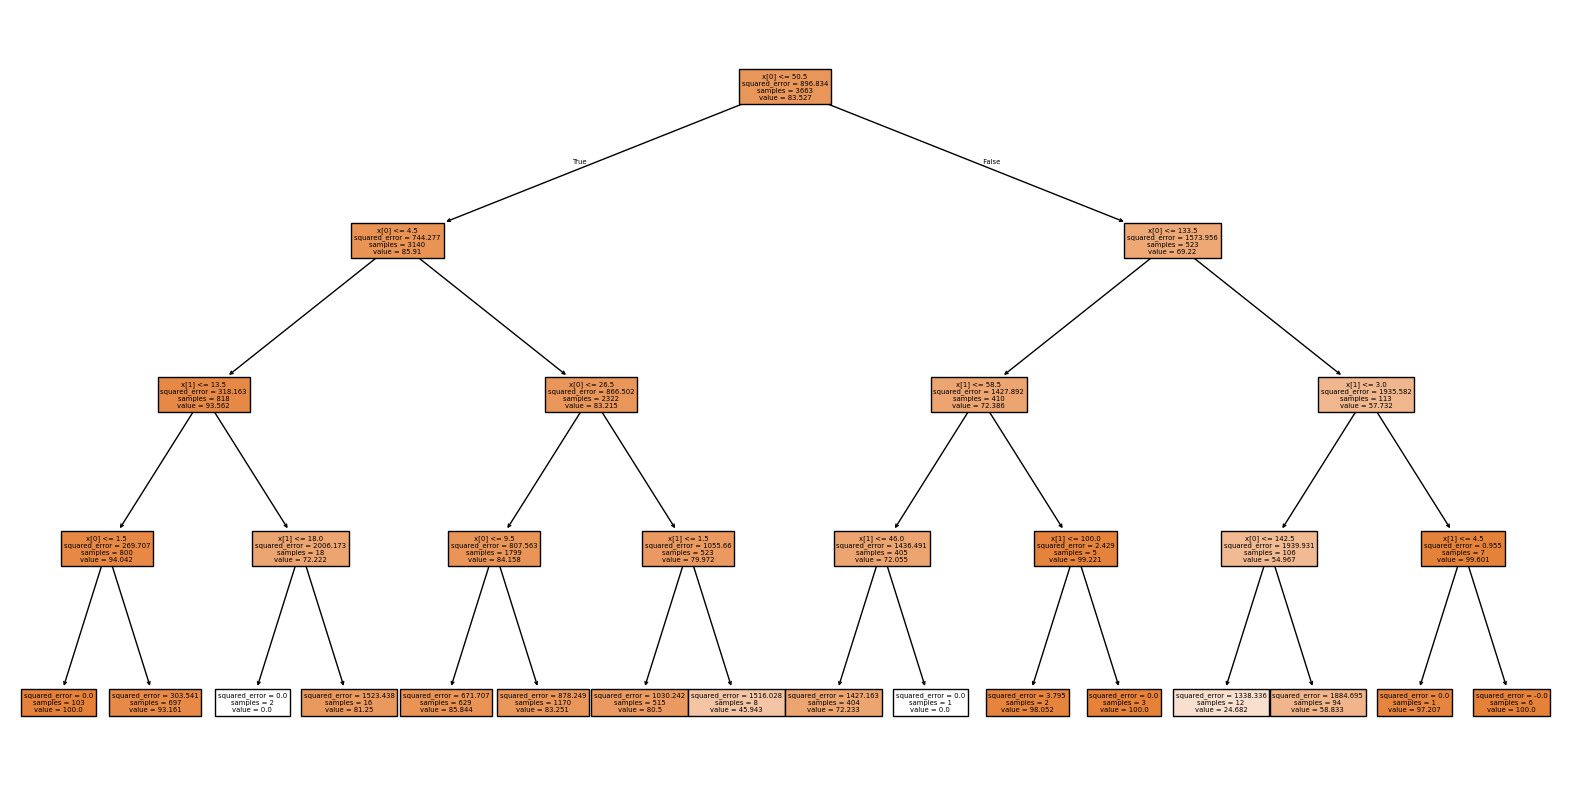

In [49]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    filled=True
)

plt.show()

<Axes: >

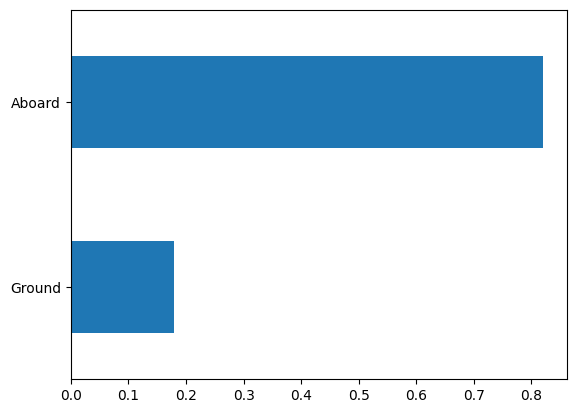

In [50]:
pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values().plot.barh()

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [74]:
# Combine X_train and y_train to drop NaNs coherently
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined.dropna(inplace=True)

X_train_cleaned = train_combined[X_train.columns]
y_train_cleaned = train_combined[y_train.name]

tree = DecisionTreeRegressor(
    max_depth=4
)

tree.fit(
    X_train_cleaned,
    y_train_cleaned
)

DecisionTreeRegressor(max_depth=4)

In [51]:
# Combine X_train and y_train to drop NaNs coherently
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined.dropna(inplace=True)

X_train_cleaned = train_combined[X_train.columns]
y_train_cleaned = train_combined[y_train.name]

tree = DecisionTreeRegressor(
    max_depth=4
)

tree.fit(
    X_train_cleaned,
    y_train_cleaned
)

DecisionTreeRegressor(max_depth=4)

In [52]:
pred = tree.predict(X_test)

r2 = r2_score(
    y_test,
    pred
)

print(r2)

0.05071438057475497


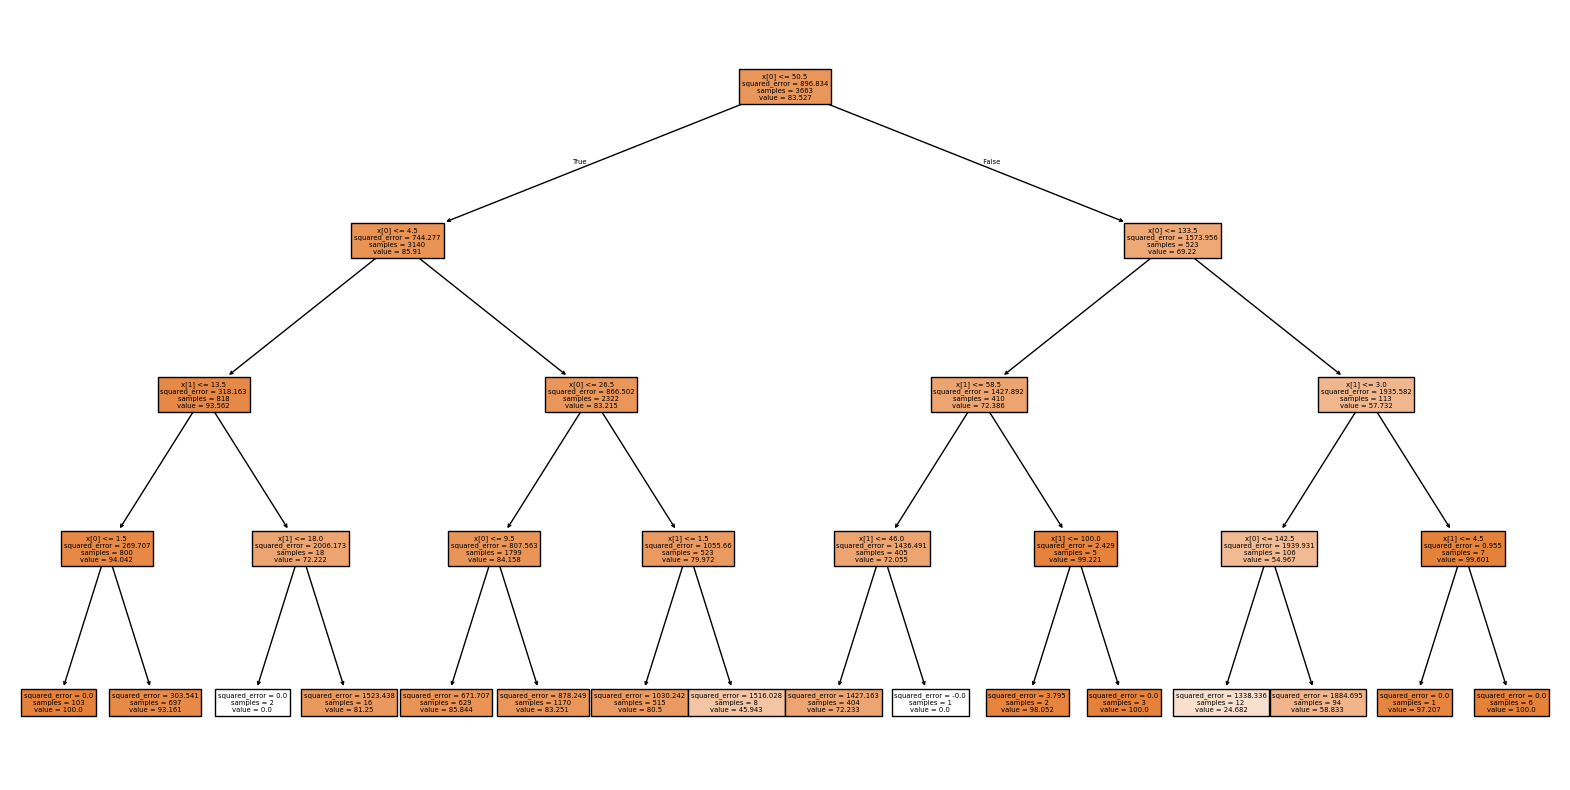

In [53]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    filled=True
)

plt.show()

<Axes: >

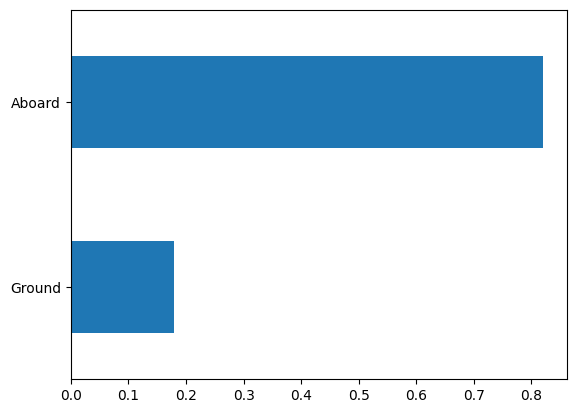

In [54]:
pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values().plot.barh()

In [64]:
# Ensure the tree model is fitted before prediction
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X_train_cleaned, y_train_cleaned)

pred = tree.predict(X_test)

r2 = r2_score(
    y_test,
    pred
)

print(r2)

0.05071438057475508


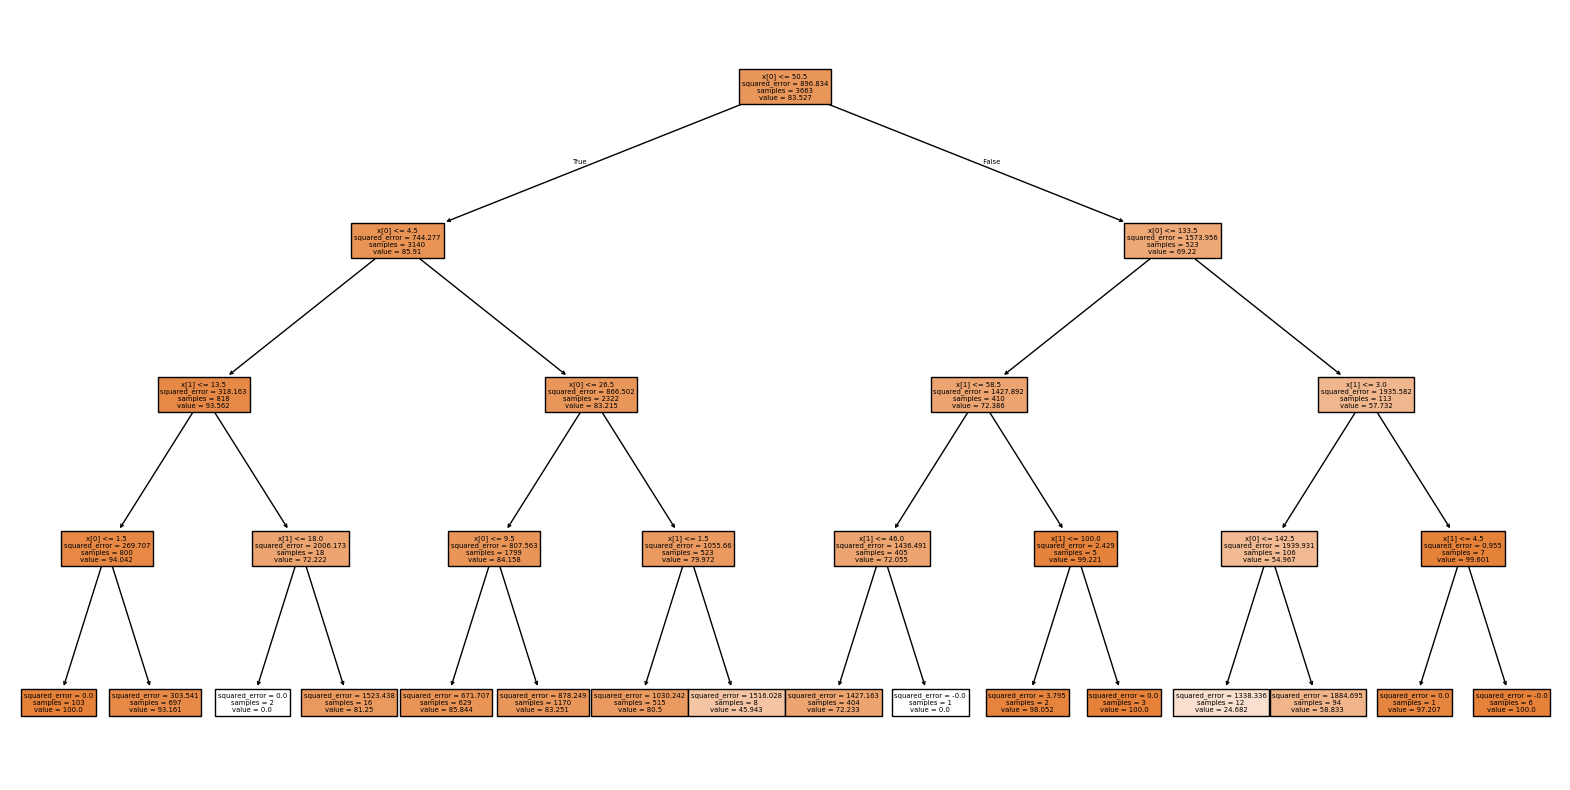

In [65]:
# Ensure the tree model is fitted before plotting
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X_train_cleaned, y_train_cleaned)

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    filled=True
)

plt.show()

<Axes: >

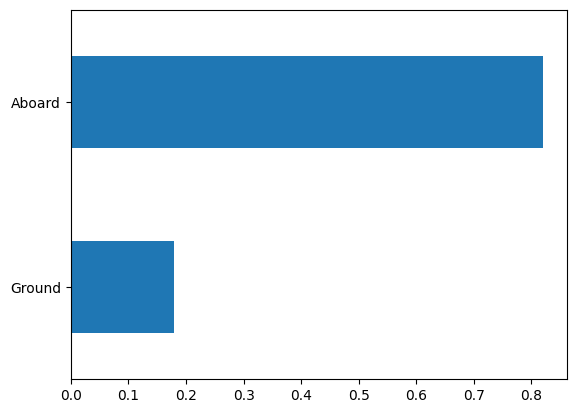

In [70]:
# Ensure the tree model is fitted before extracting feature importances
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X_train_cleaned, y_train_cleaned)

pd.Series(
    tree.feature_importances_,
    index=X_train_cleaned.columns  # Corrected to use X_train_cleaned.columns, assuming this is now correctly referenced
).sort_values().plot.barh()

R^2

In [ ]:
pred = tree.predict(X_test)

r2 = r2_score(
    y_test,
    pred
)

print(r2)

Wizualizacja

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    filled=True
)

plt.show()

Ważność predyktorów

In [ ]:
pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values().plot.barh()

Macierz klasyfikacji (H3)

In [61]:
y = LabelEncoder().fit_transform(
    df["OperatorType"]
)

X = pd.get_dummies(
    df[
        [
            "Decade"
        ]
    ],
    drop_first=True # Drop one to avoid multicollinearity
)

In [62]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

clf = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

clf.fit(
    X_train_clf,
    y_train_clf
)

DecisionTreeClassifier(max_depth=5, random_state=42)

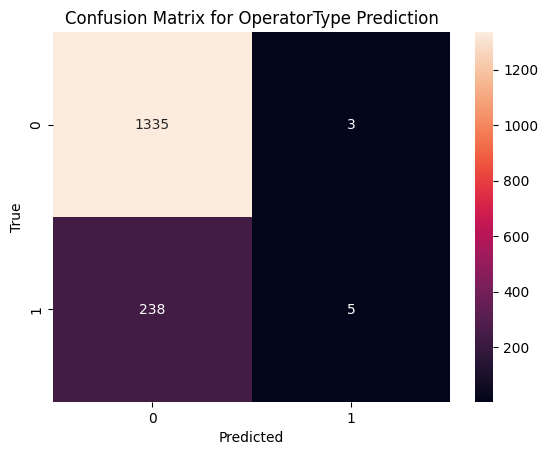

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1338
           1       0.62      0.02      0.04       243

    accuracy                           0.85      1581
   macro avg       0.74      0.51      0.48      1581
weighted avg       0.81      0.85      0.78      1581



In [63]:
pred = clf.predict(X_test_clf)

cm = confusion_matrix(
    y_test_clf,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title('Confusion Matrix for OperatorType Prediction')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_test_clf, pred))

#K-Means

In [55]:
cluster_data = df[
    [
        "Aboard",
        "Fatalities",
        "Ground",
        "FatalityRate"
    ]
].fillna(0)

In [56]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_data
)

In [57]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto'
)

clusters = kmeans.fit_predict(
    X_scaled
)

df["Cluster"] = clusters

Charakterystyka skupień

In [58]:
df.groupby(
    "Cluster"
)[
    [
        "Aboard",
        "Fatalities",
        "Ground",
        "FatalityRate"
    ]
].mean()

,Aboard,Fatalities,Ground,FatalityRate
Cluster,,,,
0,15.688367,15.010598,0.441325,96.653329
1,34.617297,5.977540,0.858672,25.216946
2,140.662011,112.857542,16.460894,88.060743


#EM

In [59]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

df["EM_Cluster"] = gmm.fit_predict(
    X_scaled
)

In [60]:
df.groupby(
    "EM_Cluster"
)[
    [
        "Aboard",
        "Fatalities",
        "Ground",
        "FatalityRate"
    ]
].mean()

,Aboard,Fatalities,Ground,FatalityRate
EM_Cluster,,,,
0,19.429079,19.429079,0.000000,100.000000
1,25.371795,12.989940,0.000000,52.051813
2,106.816537,52.832474,21.752577,59.733358


#Random Forest

In [71]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=500, random_state=42)

R^2

In [72]:
pred = rf.predict(
    X_test
)

print(
    r2_score(
        y_test,
        pred
    )
)

-0.050648235810674125


Ważność cech

<Axes: >

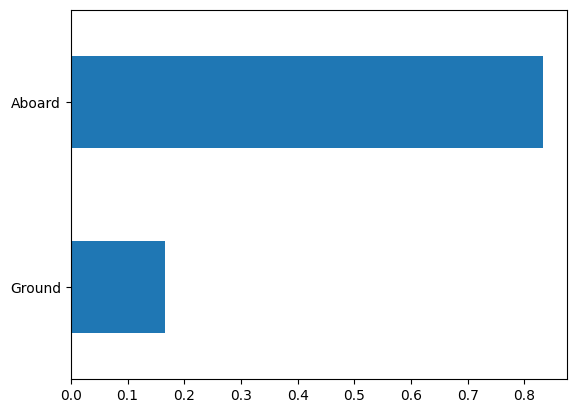

In [73]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train_cleaned.columns # Use X_train_cleaned.columns to match the features used for training
)

importance.sort_values().plot.barh()